In [39]:
import numpy as np

In [40]:
rain = np.fromfile(
    "../data/raw/Rainfall_ind2024_rfp25.grd",
    dtype=np.float32
)

print(rain.shape)

(6373890,)


In [41]:
rain = rain.reshape(366,129,135)

print(rain.shape)

(366, 129, 135)


In [42]:
print(rain.min())
print(rain.max())

-999.0
660.5492


In [43]:
rain = np.where(
    rain == -999,
    np.nan,
    rain
)

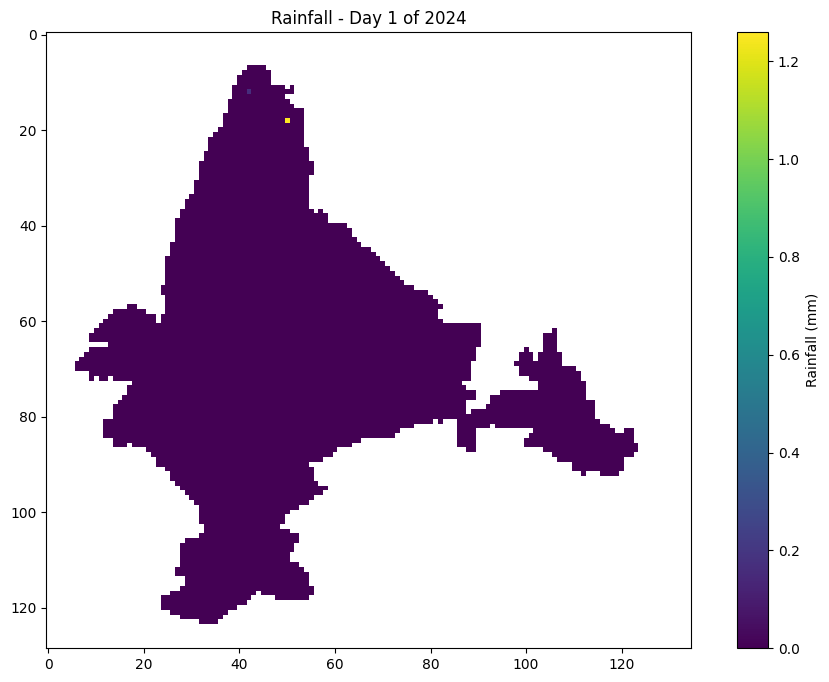

In [44]:
import matplotlib.pyplot as plt

day0 = rain[0]

plt.figure(figsize=(12,8))
plt.imshow(day0)
plt.colorbar(label="Rainfall (mm)")
plt.title("Rainfall - Day 1 of 2024")
plt.show()

In [45]:
print("Mean:", np.nanmean(rain))
print("Median:", np.nanmedian(rain))
print("Max:", np.nanmax(rain))

Mean: 3.3205583
Median: 0.0
Max: 660.5492


In [46]:
rain = np.fromfile(
    "../data/raw/Rainfall_ind2024_rfp25.grd",
    dtype=np.float32
)

print(rain.shape)

(6373890,)


In [47]:
rain = np.where(
    rain == -999,
    np.nan,
    rain
)

In [48]:
latitudes = np.linspace(
    38.5,
    6.5,
    129
)

longitudes = np.linspace(
    66.5,
    100.0,
    135
)

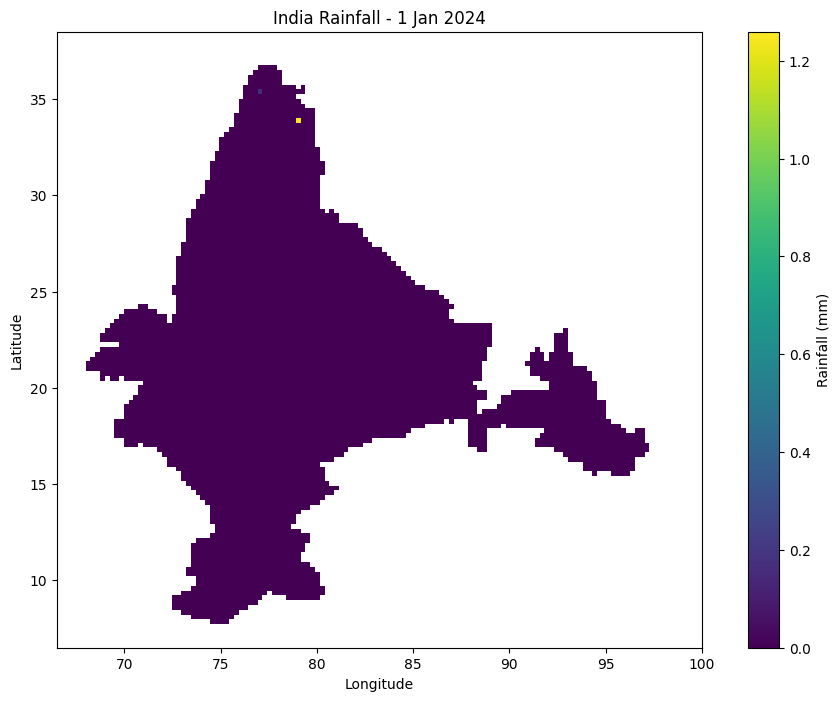

In [49]:
plt.figure(figsize=(12,8))

plt.imshow(
    day0,
    extent=[
        longitudes.min(),
        longitudes.max(),
        latitudes.min(),
        latitudes.max()
    ]
)

plt.colorbar(label="Rainfall (mm)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("India Rainfall - 1 Jan 2024")

plt.show()

In [50]:
print(np.nanmin(day0))
print(np.nanmax(day0))
print(np.nanmean(day0))

0.0
1.2592779
0.00028648382


In [51]:
daily_mean = np.nanmean(
    rain,
    axis=(1,2)
)

wettest_day = np.argmax(daily_mean)

print("Wettest Day Index:", wettest_day)
print("Mean Rainfall:", daily_mean[wettest_day])

AxisError: axis 1 is out of bounds for array of dimension 1

In [ ]:
print(rain.shape)

(6373890,)


In [ ]:
rain = np.fromfile(
    "../data/raw/Rainfall_ind2024_rfp25.grd",
    dtype=np.float32
)

rain = rain.reshape(366,129,135)

rain = np.where(
    rain == -999,
    np.nan,
    rain
)

print(rain.shape)

(366, 129, 135)


In [ ]:
daily_mean = np.nanmean(
    rain,
    axis=(1,2)
)

In [ ]:
daily_mean = np.nanmean(
    rain,
    axis=(1,2)
)

wettest_day = np.argmax(daily_mean)

print("Wettest Day Index:", wettest_day)
print("Mean Rainfall:", daily_mean[wettest_day])

Wettest Day Index: 215
Mean Rainfall: 15.829672


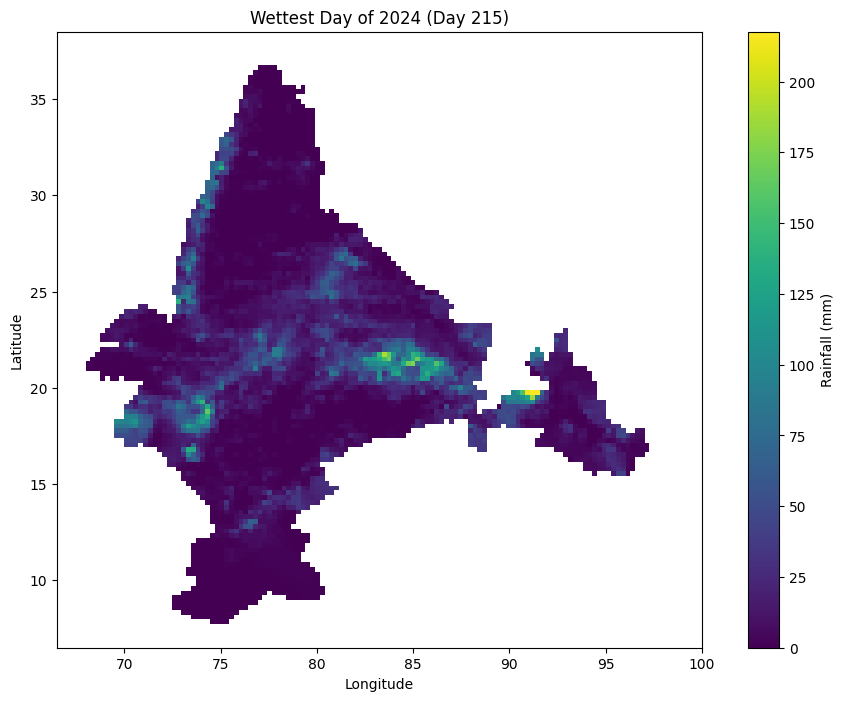

In [ ]:
wettest = rain[wettest_day]

plt.figure(figsize=(12,8))

plt.imshow(
    wettest,
    extent=[
        longitudes.min(),
        longitudes.max(),
        latitudes.min(),
        latitudes.max()
    ]
)

plt.colorbar(label="Rainfall (mm)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Wettest Day of 2024 (Day {wettest_day})")

plt.show()

In [ ]:
#Temp data

In [ ]:
temp = np.fromfile(
    "../data/raw/Maxtemp_MaxT_2024.GRD",
    dtype=np.float32
)

print(temp.shape)

(351726,)


In [ ]:
temp = temp.reshape(366,31,31)

print(temp.shape)

(366, 31, 31)


In [ ]:
print(temp.min())
print(temp.max())

3.5872378
99.9


In [ ]:
temp = np.where(
    temp == 99.9,
    np.nan,
    temp
)

In [ ]:
print("Min:", np.nanmin(temp))
print("Max:", np.nanmax(temp))
print("Mean:", np.nanmean(temp))

Min: 3.5872378
Max: 48.09463
Mean: 30.920702


In [ ]:
print(temp.shape)

(366, 31, 31)


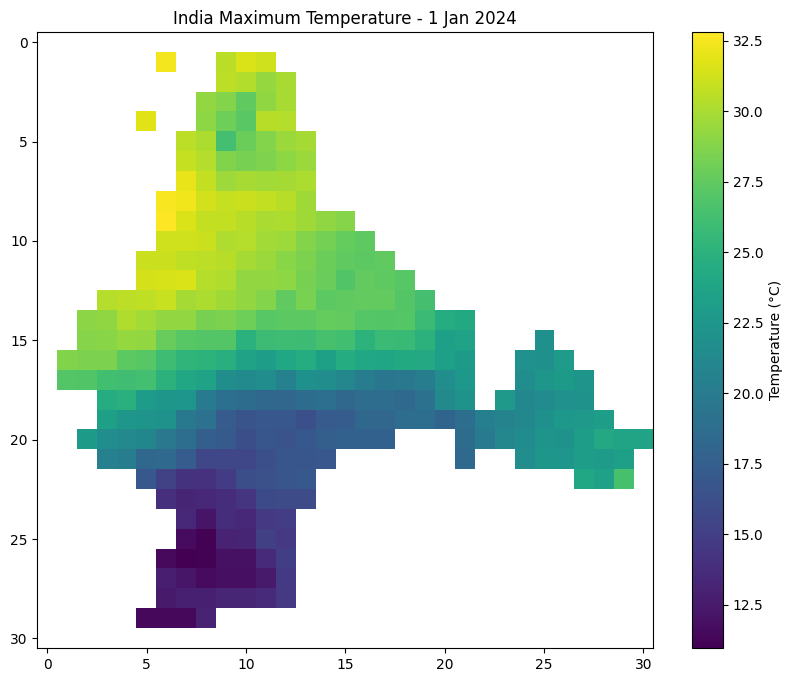

In [ ]:
day0_temp = temp[0]

plt.figure(figsize=(10,8))

plt.imshow(day0_temp)

plt.colorbar(label="Temperature (°C)")
plt.title("India Maximum Temperature - 1 Jan 2024")

plt.show()

In [ ]:
from dataclasses import dataclass


@dataclass
class ClimateState:
    date: str
    latitude: float
    longitude: float
    rainfall_mm: float
    max_temperature_c: float

In [ ]:
state = ClimateState(
    date="2024-01-01",
    latitude=19.07,
    longitude=72.88,
    rainfall_mm=0.0,
    max_temperature_c=31.2
)

print(state)

ClimateState(date='2024-01-01', latitude=19.07, longitude=72.88, rainfall_mm=0.0, max_temperature_c=31.2)


In [ ]:
import sys
sys.path.append("..")

In [ ]:
from src.ingest import (
    load_rainfall,
    load_temperature
)

In [ ]:
rain = load_rainfall()

print(rain.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/Rainfall_ind2024_rfp25.grd'

In [ ]:
import os
print(os.getcwd())

e:\ClimateTwinIndia\notebooks


In [ ]:
from src.ingest import load_rainfall

rain = load_rainfall()

print(rain.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/Rainfall_ind2024_rfp25.grd'

In [52]:
import importlib
import src.ingest

importlib.reload(src.ingest)

from src.ingest import load_rainfall

rain = load_rainfall()

print(rain.shape)

Loading rainfall from: E:\ClimateTwinIndia\data\raw\Rainfall_ind2024_rfp25.grd
(366, 129, 135)


In [53]:
from src.ingest import load_temperature

temp = load_temperature()

print(temp.shape)

Loading temperature from: E:\ClimateTwinIndia\data\raw\Maxtemp_MaxT_2024.GRD
(366, 31, 31)


In [54]:
from src.region import (
    get_rainfall_latitudes,
    get_rainfall_longitudes
)

latitudes = get_rainfall_latitudes()
longitudes = get_rainfall_longitudes()

print(latitudes.shape)
print(longitudes.shape)

(129,)
(135,)


In [55]:
lat_mask = (
    (latitudes >= 15)
    &
    (latitudes <= 23)
)

lon_mask = (
    (longitudes >= 72)
    &
    (longitudes <= 81)
)

print(lat_mask.sum())
print(lon_mask.sum())

33
37


In [56]:
maha_rain = rain[
    215,
    lat_mask,
    :
][:,
    lon_mask
]

print(maha_rain.shape)

(33, 37)


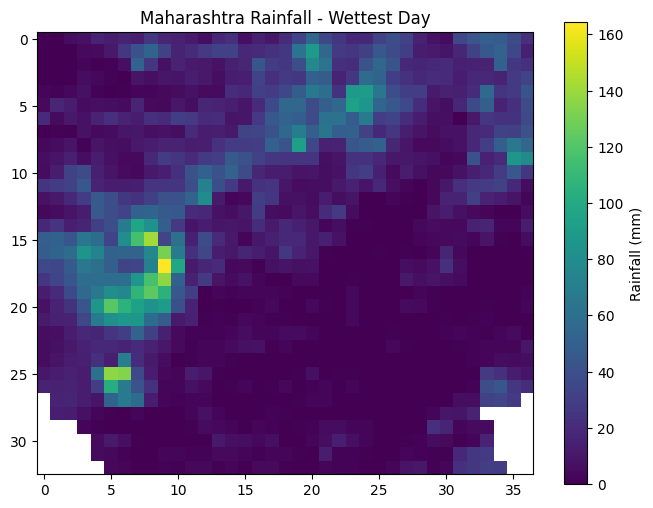

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(maha_rain)

plt.colorbar(
    label="Rainfall (mm)"
)

plt.title(
    "Maharashtra Rainfall - Wettest Day"
)

plt.show()

In [58]:
from src.climate_state import ClimateState

mumbai_state = ClimateState(
    date="2024-08-03",
    latitude=19.07,
    longitude=72.88,
    rainfall_mm=120.5,
    max_temperature_c=28.7
)

print(mumbai_state)

ClimateState(date='2024-08-03', latitude=19.07, longitude=72.88, rainfall_mm=120.5, max_temperature_c=28.7)


In [59]:
from src.trust import (
    completeness_score,
    anomaly_score
)

score = completeness_score(
    rainfall=120.5,
    temperature=28.7
)

print(score)

1.0


In [60]:
rain_mean = np.nanmean(rain)
rain_std = np.nanstd(rain)

print(rain_mean)
print(rain_std)

3.3205583
11.728829


In [61]:
anomaly = anomaly_score(
    rainfall=120.5,
    rainfall_mean=rain_mean,
    rainfall_std=rain_std
)

print(anomaly)

9.990719265794256


In [67]:
from src.climate_state import ClimateState

mumbai_state = ClimateState(
    date="2024-08-03",
    latitude=19.07,
    longitude=72.88,

    rainfall_mm=120.5,
    max_temperature_c=28.7,

    completeness_score=1.0,
    anomaly_score=4.2
)

print(mumbai_state)

TypeError: ClimateState.__init__() got an unexpected keyword argument 'completeness_score'

In [68]:
import importlib
import src.climate_state

importlib.reload(src.climate_state)

from src.climate_state import ClimateState

In [69]:
help(ClimateState)

Help on class ClimateState in module src.climate_state:

class ClimateState(builtins.object)
 |  ClimateState(date: str, latitude: float, longitude: float, rainfall_mm: float, max_temperature_c: float, completeness_score: float, anomaly_score: float) -> None
 |  
 |  ClimateState(date: str, latitude: float, longitude: float, rainfall_mm: float, max_temperature_c: float, completeness_score: float, anomaly_score: float)
 |  
 |  Methods defined here:
 |  
 |  __eq__(self, other)
 |      Return self==value.
 |  
 |  __init__(self, date: str, latitude: float, longitude: float, rainfall_mm: float, max_temperature_c: float, completeness_score: float, anomaly_score: float) -> None
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  __repr__(self)
 |      Return repr(self).
 |  
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |  
 |  __dict__
 |      dictionary for instance variables
 |  
 |  __weakref__

In [70]:
mumbai_state = ClimateState(
    date="2024-08-03",
    latitude=19.07,
    longitude=72.88,
    rainfall_mm=120.5,
    max_temperature_c=28.7,
    completeness_score=1.0,
    anomaly_score=4.2
)

print(mumbai_state)

ClimateState(date='2024-08-03', latitude=19.07, longitude=72.88, rainfall_mm=120.5, max_temperature_c=28.7, completeness_score=1.0, anomaly_score=4.2)


In [71]:
from src.state_engine import create_climate_state

state = create_climate_state(
    date="2024-08-03",
    latitude=19.07,
    longitude=72.88,
    rainfall=120.5,
    temperature=28.7,
    completeness_score=1.0,
    anomaly_score=4.2
)

print(state)

ClimateState(date='2024-08-03', latitude=19.07, longitude=72.88, rainfall_mm=120.5, max_temperature_c=28.7, completeness_score=1.0, anomaly_score=4.2)


In [72]:
daily_rain = np.nanmean(
    rain[:, lat_mask, :][:, :, lon_mask],
    axis=(1,2)
)

print(daily_rain.shape)

(366,)


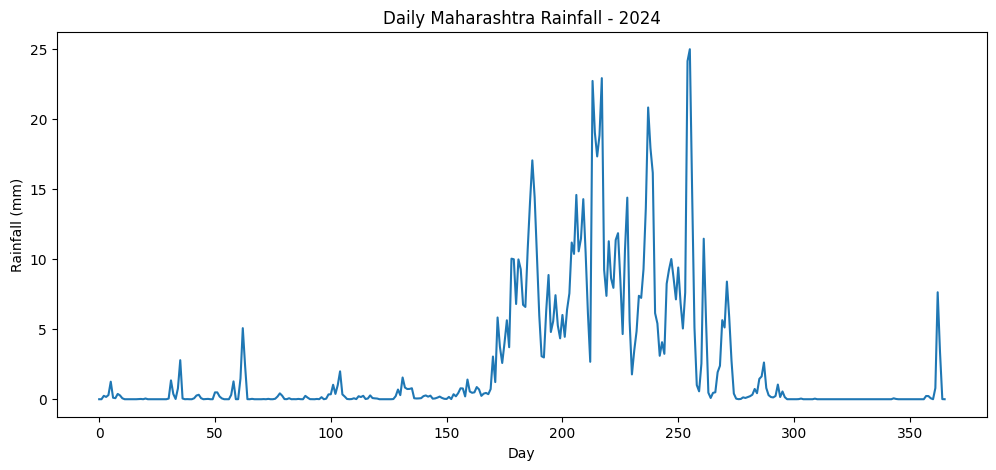

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(daily_rain)
plt.title("Daily Maharashtra Rainfall - 2024")
plt.xlabel("Day")
plt.ylabel("Rainfall (mm)")
plt.show()

In [74]:
daily_temp = np.nanmean(
    temp,
    axis=(1,2)
)

print(daily_temp.shape)

(366,)


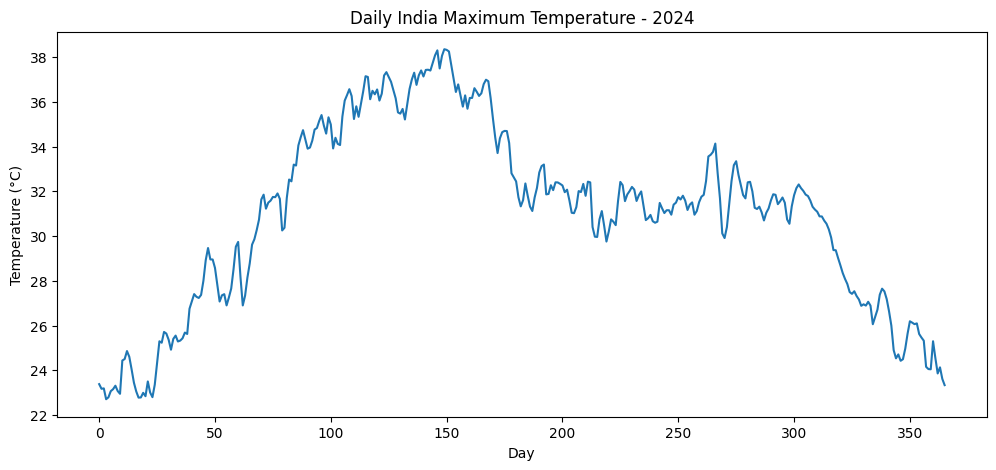

In [75]:
plt.figure(figsize=(12,5))

plt.plot(daily_temp)

plt.title("Daily India Maximum Temperature - 2024")
plt.xlabel("Day")
plt.ylabel("Temperature (°C)")

plt.show()

In [76]:
import pandas as pd

climate_df = pd.DataFrame({
    "day": np.arange(366),
    "rainfall": daily_rain,
    "temperature": daily_temp
})

climate_df.head()

,day,rainfall,temperature
0,0,0.000000,23.385981
1,1,0.000000,23.178064
2,2,0.242088,23.195887
3,3,0.163972,22.711435
4,4,0.296261,22.796724


In [77]:
print(climate_df.shape)

(366, 3)


In [78]:
climate_df.to_csv(
    "../data/processed/climate_2024.csv",
    index=False
)

In [79]:
print(
    climate_df[
        ["rainfall","temperature"]
    ].corr()
)

             rainfall  temperature
rainfall     1.000000     0.060546
temperature  0.060546     1.000000


In [2]:
import numpy as np

In [4]:
for year in range(2019, 2026):
    rain = np.fromfile(
        f"../data/raw/rainfall/Rainfall_ind{year}_rfp25.grd",
        dtype=np.float32
    )

    print(year, rain.shape)

2019 (6356475,)
2020 (6373890,)
2021 (6356475,)
2022 (6356475,)
2023 (6356475,)
2024 (6373890,)
2025 (6356475,)


In [5]:
for year in range(2019, 2026):

    rain = np.fromfile(
        f"../data/raw/rainfall/Rainfall_ind{year}_rfp25.grd",
        dtype=np.float32
    )

    days = 366 if year % 4 == 0 else 365

    print(
        year,
        rain.size,
        rain.size / (129 * 135)
    )

2019 6356475 365.0
2020 6373890 366.0
2021 6356475 365.0
2022 6356475 365.0
2023 6356475 365.0
2024 6373890 366.0
2025 6356475 365.0


In [6]:
for year in range(2019, 2026):

    rain = np.fromfile(
        f"../data/raw/rainfall/Rainfall_ind{year}_rfp25.grd",
        dtype=np.float32
    )

    days = 366 if year in [2020, 2024] else 365

    rain = rain.reshape(days,129,135)

    print(year, rain.shape)

2019 (365, 129, 135)
2020 (366, 129, 135)
2021 (365, 129, 135)
2022 (365, 129, 135)
2023 (365, 129, 135)
2024 (366, 129, 135)
2025 (365, 129, 135)


In [7]:
rain = rain.reshape(days,129,135)

print(np.min(rain))
print(np.max(rain))

-999.0
469.21014


In [8]:
import numpy as np

def load_rainfall(year):

    path = f"data/raw/rainfall/Rainfall_ind{year}_rfp25.grd"

    rain = np.fromfile(path,dtype=np.float32)

    days = 366 if year in [2020,2024] else 365

    rain = rain.reshape(days,129,135)

    rain[rain == -999] = np.nan

    return rain

In [10]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [11]:
from src.loaders import load_rainfall

In [13]:
import os

print(os.getcwd())

e:\ClimateTwinIndia\notebooks


In [14]:
import os

print(os.path.exists("data/raw/rainfall"))
print(os.path.exists("../data/raw/rainfall"))

False
True


In [18]:
import importlib
import src.loaders

importlib.reload(src.loaders)

from src.loaders import load_rainfall

In [19]:
from src.loaders import load_rainfall

rain_2024 = load_rainfall(2024)

print(rain_2024.shape)
print(np.nanmean(rain_2024))

(366, 129, 135)
3.3205583


In [20]:
all_rain = {}

for year in range(2019, 2026):
    all_rain[year] = load_rainfall(year)

    print(
        year,
        all_rain[year].shape,
        np.nanmean(all_rain[year])
    )

2019 (365, 129, 135) 3.4766786
2020 (366, 129, 135) 3.4876978
2021 (365, 129, 135) 3.356477
2022 (365, 129, 135) 3.4443238
2023 (365, 129, 135) 2.9621644
2024 (366, 129, 135) 3.3205583
2025 (365, 129, 135) 3.4739628


In [21]:
import numpy as np

vals = [3.4766786,3.4876978,3.356477,3.4443238,2.9621644,3.3205583]

print("Mean:",np.mean(vals))
print("Std:",np.std(vals))

Mean: 3.3413166499999996
Std: 0.18017488981595772


In [22]:
climatology = np.mean(vals)

print("2025 anomaly:",3.4739628-climatology)

2025 anomaly: 0.13264615000000024


In [24]:
annual_grids = []

for year in range(2019, 2025):

    annual_grid = np.nanmean(all_rain[year], axis=0)

    annual_grids.append(annual_grid)

baseline_grid = np.nanmean(
    np.stack(annual_grids),
    axis=0
)

print(baseline_grid.shape)

(129, 135)


C:\Users\Aaditya\AppData\Local\Temp\ipykernel_30688\1538901562.py:5: RuntimeWarning: Mean of empty slice
  annual_grid = np.nanmean(all_rain[year], axis=0)
C:\Users\Aaditya\AppData\Local\Temp\ipykernel_30688\1538901562.py:9: RuntimeWarning: Mean of empty slice
  baseline_grid = np.nanmean(


In [25]:
rain_2025_grid = np.nanmean(all_rain[2025], axis=0)

anomaly_grid = rain_2025_grid - baseline_grid

print(np.nanmin(anomaly_grid))
print(np.nanmax(anomaly_grid))
print(np.nanmean(anomaly_grid))

-11.494356
7.2810364
0.13265127


C:\Users\Aaditya\AppData\Local\Temp\ipykernel_30688\3162284101.py:1: RuntimeWarning: Mean of empty slice
  rain_2025_grid = np.nanmean(all_rain[2025], axis=0)


In [26]:
print(np.isnan(baseline_grid).sum())
print(baseline_grid.size)

12451
17415


In [27]:
print(
    100 * np.isnan(baseline_grid).sum() / baseline_grid.size
)

71.4958369221935


In [28]:
max_idx = np.unravel_index(
    np.nanargmax(anomaly_grid),
    anomaly_grid.shape
)

min_idx = np.unravel_index(
    np.nanargmin(anomaly_grid),
    anomaly_grid.shape
)

print("Max:", max_idx, anomaly_grid[max_idx])
print("Min:", min_idx, anomaly_grid[min_idx])

Max: (15, 42) 7.2810364
Min: (76, 97) -11.494356


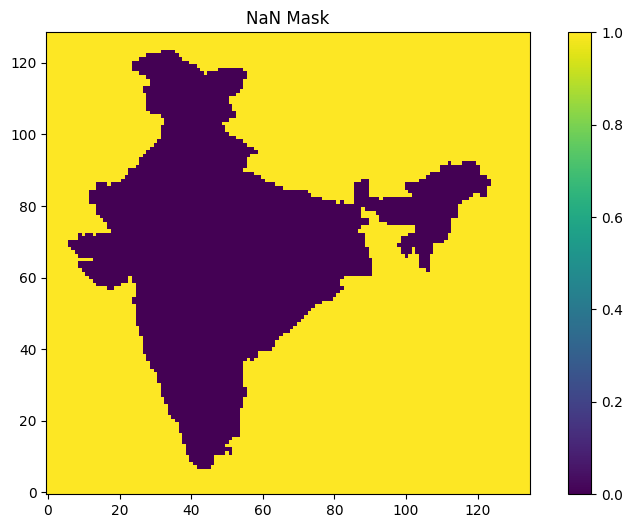

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.imshow(
    np.isnan(baseline_grid),
    origin="lower"
)

plt.colorbar()

plt.title("NaN Mask")
plt.show()

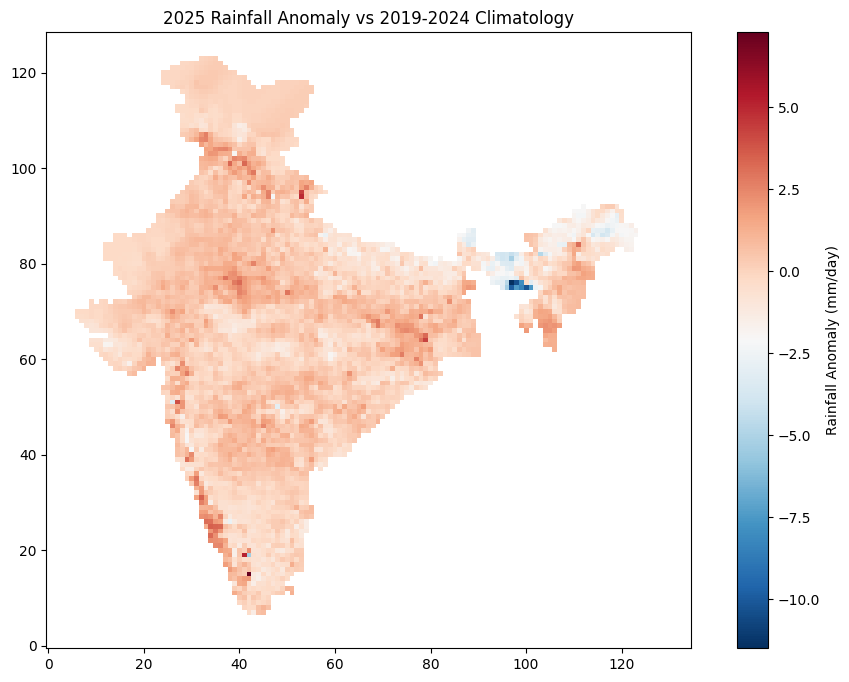

In [30]:
plt.figure(figsize=(12,8))

plt.imshow(
    anomaly_grid,
    origin="lower",
    cmap="RdBu_r"
)

plt.colorbar(
    label="Rainfall Anomaly (mm/day)"
)

plt.title(
    "2025 Rainfall Anomaly vs 2019-2024 Climatology"
)

plt.show()

In [33]:
import os

os.makedirs("docs/images", exist_ok=True)

plt.savefig(
    "docs/images/rainfall_anomaly_2025.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [12]:
from src.loaders import load_temperature

for year in range(2019, 2026):

    temp = load_temperature(year)

    print(
        year,
        temp.shape,
        np.nanmean(temp)
    )

ModuleNotFoundError: No module named 'src.loaders'

In [13]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

print(sys.path[-1])

e:\ClimateTwinIndia


In [14]:
from src.loaders import load_temperature

In [15]:
import os

print(os.getcwd())

e:\ClimateTwinIndia\notebooks


In [16]:
import os

print(os.getcwd())

print(
    os.path.exists("../src/loaders.py")
)

print(
    os.path.exists("src/loaders.py")
)

e:\ClimateTwinIndia\notebooks
True
False


In [18]:
import numpy as np


In [19]:
from src.loaders import load_temperature

for year in range(2019, 2026):

    temp = load_temperature(year)

    print(
        year,
        temp.shape,
        np.nanmean(temp)
    )

2019 (365, 31, 31) 30.6359
2020 (366, 31, 31) 30.461535
2021 (365, 31, 31) 30.712994
2022 (365, 31, 31) 30.910982
2023 (365, 31, 31) 30.869696
2024 (366, 31, 31) 30.920702
2025 (365, 31, 31) 30.604105


In [20]:
all_temp = {}

for year in range(2019, 2025):
    all_temp[year] = load_temperature(year)

annual_grids = []

for year in range(2019, 2025):

    annual_grid = np.nanmean(
        all_temp[year],
        axis=0
    )

    annual_grids.append(
        annual_grid
    )

temp_climatology = np.nanmean(
    np.stack(annual_grids),
    axis=0
)

print(temp_climatology.shape)
print(np.nanmean(temp_climatology))

(31, 31)
30.742105


C:\Users\Aaditya\AppData\Local\Temp\ipykernel_28328\2074873823.py:10: RuntimeWarning: Mean of empty slice
  annual_grid = np.nanmean(
C:\Users\Aaditya\AppData\Local\Temp\ipykernel_28328\2074873823.py:19: RuntimeWarning: Mean of empty slice
  temp_climatology = np.nanmean(


In [21]:
temp_2025 = load_temperature(2025)

temp_2025_grid = np.nanmean(
    temp_2025,
    axis=0
)

temp_anomaly = (
    temp_2025_grid
    -
    temp_climatology
)

print(
    np.nanmin(temp_anomaly),
    np.nanmax(temp_anomaly),
    np.nanmean(temp_anomaly)
)

-2.3452892 3.1097507 -0.13947092


C:\Users\Aaditya\AppData\Local\Temp\ipykernel_28328\282998520.py:3: RuntimeWarning: Mean of empty slice
  temp_2025_grid = np.nanmean(


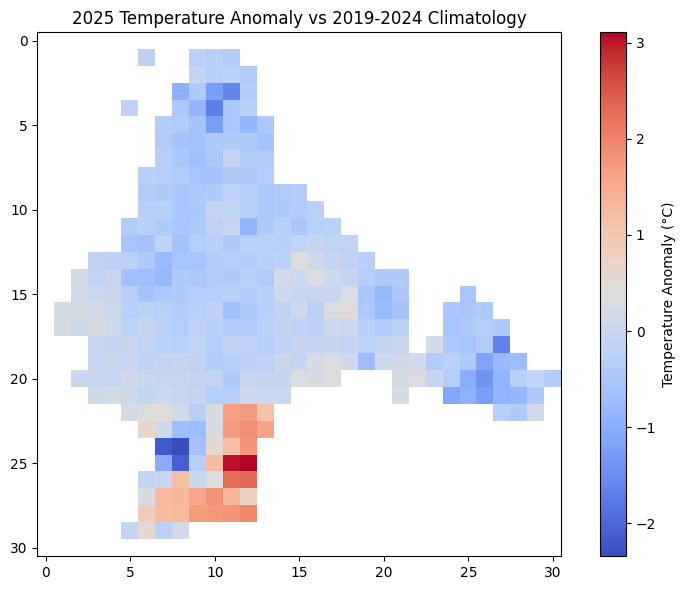

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(
    temp_anomaly,
    cmap="coolwarm"
)

plt.colorbar(
    label="Temperature Anomaly (°C)"
)

plt.title(
    "2025 Temperature Anomaly vs 2019-2024 Climatology"
)

plt.tight_layout()

plt.show()

In [23]:
print(np.nanmin(temp_anomaly))
print(np.nanmax(temp_anomaly))
print(np.nanmean(temp_anomaly))

-2.3452892
3.1097507
-0.13947092
